## Quant Question

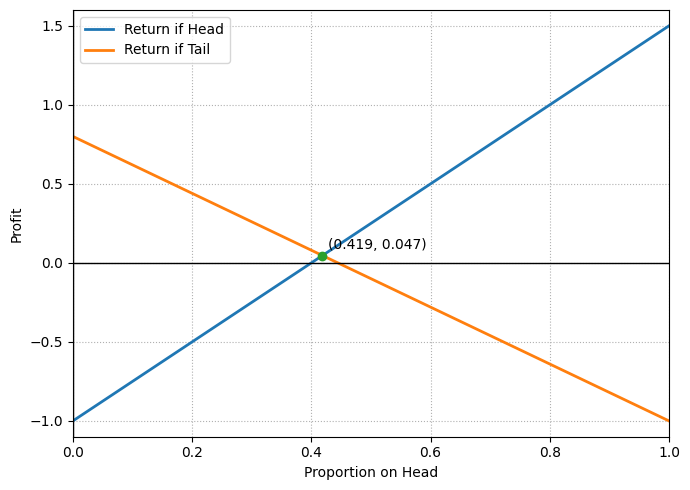

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Functions
def y1(x):  # red line in your Desmos: y = 2.5x - 1
    return 2.5*x - 1

def y2(x):  # blue line: y = 1.8(1 - x) - 1 = -1.8x + 0.8
    return -1.8*x + 0.8

# Domain and values
x = np.linspace(0, 1, 400)
Y1, Y2 = y1(x), y2(x)

# Intersection: solve 2.5x - 1 = -1.8x + 0.8
xi = 1.8 / (2.5 + 1.8)         # = 18/43 ≈ 0.4186046512
yi = y1(xi)                    # ≈ 0.0465116279

# Plot
plt.figure(figsize=(7, 5))
plt.plot(x, Y1, label='Return if Head', linewidth=2)
plt.plot(x, Y2, label='Return if Tail', linewidth=2)
plt.plot(xi, yi, 'o', ms=6)  # intersection dot
plt.text(xi+0.01, yi+0.04, f'({xi:.3f}, {yi:.3f})')

# Axes through origin
plt.axhline(0, linewidth=1, color='black')
plt.axvline(0, linewidth=1, color='black')

# Limits, labels, grid, legend
plt.xlim(0, 1)
plt.ylim(-1.1, 1.6)
plt.xlabel('Proportion on Head')
plt.ylabel('Profit')
plt.grid(True, linestyle=':')
plt.legend()
plt.tight_layout()

# Save (vector and raster)
plt.savefig('game_profit.png', dpi=600)
plt.show()


## Options Profit

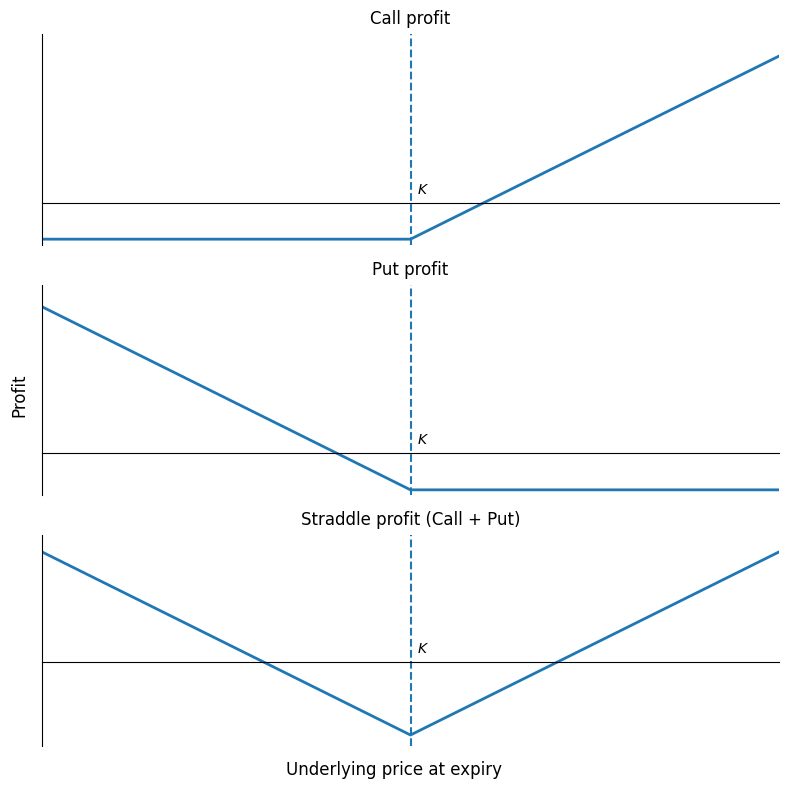

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
K  = 100.0        # strike
C0 = 5.0          # call premium
P0 = 5.0          # put premium

# Focused range around ATM
S = np.linspace(75, 125, 1001)

# Profits at expiry (ignoring financing)
call_profit = np.maximum(S - K, 0) - C0
put_profit  = np.maximum(K - S, 0) - P0
str_profit  = call_profit + put_profit   # = |S-K| - (C0+P0)

def style_axes(ax):
    """No box, no ticks; x-axis at y=0; keep left spine; label K."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_position(('data', 0))   # x-axis through y=0
    ax.set_xticks([])                                # hide tick marks/labels
    ax.set_yticks([])
    ax.set_xlim(75, 125)
    # Vertical strike marker (dashed) + label
    ax.axvline(K, linestyle='--')
    ax.annotate(r"$K$", (K, 0), xytext=(5, 5),
                textcoords="offset points", ha="left", va="bottom")

# Create figure with 3 stacked subplots sharing x
fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, ncols=1, sharex=True, figsize=(8, 8))

# 1) Call profit
ax1.plot(S, call_profit, linewidth=2)
style_axes(ax1)
# Pad y-lims to show both negative and positive parts clearly
ymin, ymax = call_profit.min(), call_profit.max()
ax1.set_ylim(ymin - 0.15*abs(ymin if ymin != 0 else 1),
             ymax + 0.15*abs(ymax if ymax != 0 else 1))
ax1.set_title("Call profit", pad=8)

# 2) Put profit
ax2.plot(S, put_profit, linewidth=2)
style_axes(ax2)
ymin, ymax = put_profit.min(), put_profit.max()
ax2.set_ylim(ymin - 0.15*abs(ymin if ymin != 0 else 1),
             ymax + 0.15*abs(ymax if ymax != 0 else 1))
ax2.set_title("Put profit", pad=8)

# 3) Straddle profit (Call + Put)
ax3.plot(S, str_profit, linewidth=2)
style_axes(ax3)
ymin, ymax = str_profit.min(), str_profit.max()
ax3.set_ylim(ymin - 0.15*abs(ymin if ymin != 0 else 1),
             ymax + 0.15*abs(ymax if ymax != 0 else 1))
ax3.set_title("Straddle profit (Call + Put)", pad=8)

# Common axis labels
fig.supxlabel("Underlying price at expiry", y=0.02)
fig.supylabel("Profit", x=0.02)

plt.tight_layout()

# Save (vector and raster)
plt.savefig('option_profit.png', dpi=600)
plt.show()



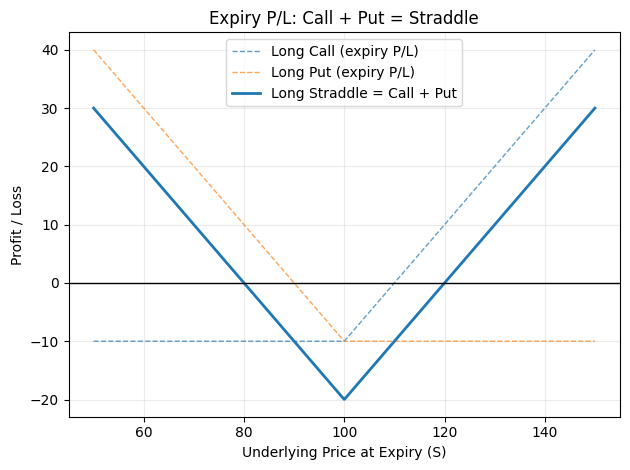

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters (edit these) ---
K = 100                 # strike
call_premium = 10        # paid for the call
put_premium  = 10        # paid for the put

# --- Underlying price range ---
S = np.linspace(50, 150, 1000)

# --- Expiry P/L (long positions) ---
call_pl = np.maximum(S - K, 0) - call_premium
put_pl  = np.maximum(K - S, 0) - put_premium
straddle_pl = call_pl + put_pl

# --- Plot ---
plt.plot(S, call_pl, label="Long Call (expiry P/L)", linewidth=1, linestyle='--', alpha=0.7)
plt.plot(S, put_pl,  label="Long Put (expiry P/L)", linewidth=1, linestyle='--', alpha=0.7)
plt.plot(S, straddle_pl, label="Long Straddle = Call + Put", linewidth=2, color='C0')

# Reference lines
plt.axhline(0, linewidth=1, color='black')

plt.title("Expiry P/L: Call + Put = Straddle")
plt.xlabel("Underlying Price at Expiry (S)")
plt.ylabel("Profit / Loss")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()

# save figure to path (BEFORE show)
plt.savefig('straddle_profit.png', dpi=600)
plt.show()

## Realised Volatility

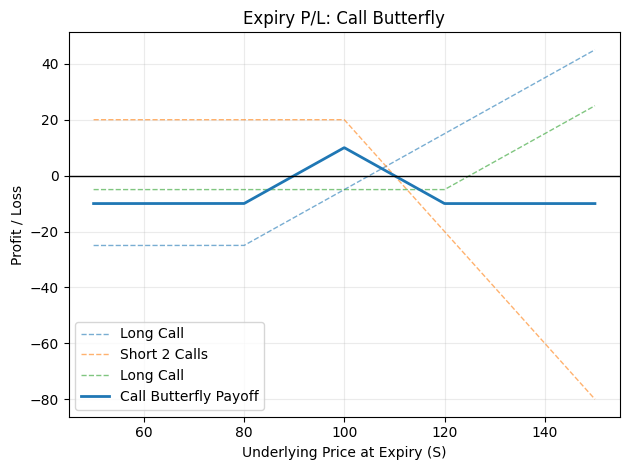

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters (edit these) ---
K = 100          # middle strike
width = 20       # distance between strikes
premium_low  = 25   # call at lower strike (more expensive, deeper ITM/ATM)
premium_mid  = 10   # call at middle strike (ATM)
premium_high = 5    # call at higher strike (less expensive, OTM)

K1 = K - width   # lower strike (90)
K2 = K           # middle strike (100)
K3 = K + width   # upper strike (110)

# Net cost of butterfly: long K1 - 2*short K2 + long K3
net_cost = premium_low - 2*premium_mid + premium_high

# --- Underlying price range ---
S = np.linspace(50, 150, 1000)

# --- Expiry P/L components (long call butterfly) ---
call_low  = np.maximum(S - K1, 0) - premium_low
call_mid  = np.maximum(S - K2, 0) - premium_mid
call_high = np.maximum(S - K3, 0) - premium_high

# Long 1 call at K1, short 2 calls at K2, long 1 call at K3
butterfly_pl = call_low - 2 * call_mid + call_high

# --- Plot ---
plt.plot(S, call_low,  label=f"Long Call", linewidth=1, linestyle='--', alpha=0.6)
plt.plot(S, -2*call_mid, label=f"Short 2 Calls", linewidth=1, linestyle='--', alpha=0.6)
plt.plot(S, call_high, label=f"Long Call", linewidth=1, linestyle='--', alpha=0.6)

plt.plot(S, butterfly_pl, label="Call Butterfly Payoff", linewidth=2, color='C0')

# Reference lines
plt.axhline(0, linewidth=1, color='black')

plt.title(f"Expiry P/L: Call Butterfly")
plt.xlabel("Underlying Price at Expiry (S)")
plt.ylabel("Profit / Loss")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()

# save figure to path (BEFORE show)
plt.savefig('butterfly_profit.png', dpi=600)
plt.show()

Realised variance RV(S1): 0.00025
Realised variance RV(S2): 0.00617
Realised volatility RV^(1/2)(S1): 0.01572
Realised volatility RV^(1/2)(S2): 0.07853


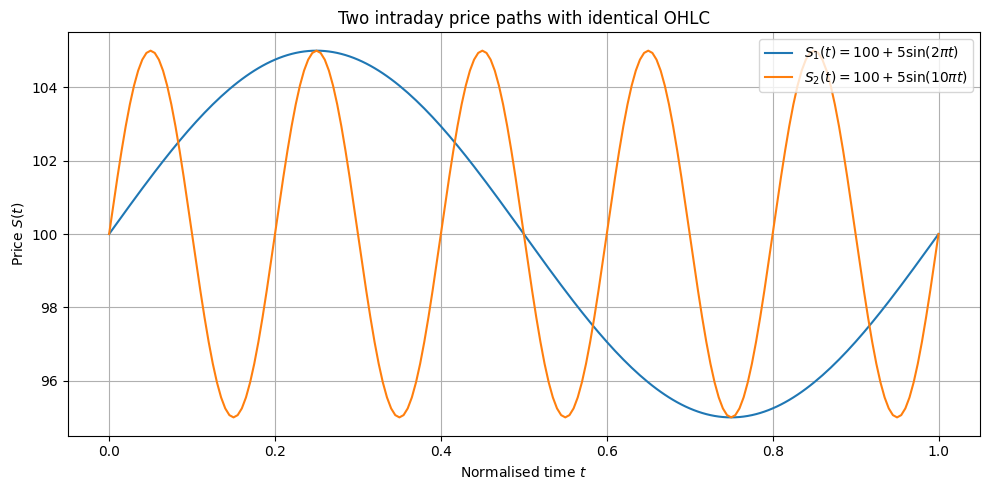

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 200 evenly spaced observation points on [0, 1]
t = np.linspace(0, 1, 201)

# Price paths
S1 = 100 + 5*np.sin(2*np.pi*t)
S2 = 100 + 5*np.sin(10*np.pi*t)

# Realised variance from log returns: sum (log(S_{j+1}/S_j))^2
rv1 = np.sum(np.diff(np.log(S1))**2)
rv2 = np.sum(np.diff(np.log(S2))**2)

print(f"Realised variance RV(S1): {rv1:.5f}")
print(f"Realised variance RV(S2): {rv2:.5f}")
print(f"Realised volatility RV^(1/2)(S1): {np.sqrt(rv1):.5f}")
print(f"Realised volatility RV^(1/2)(S2): {np.sqrt(rv2):.5f}")

# Plot
plt.figure(figsize=(6, 3))
plt.plot(t, S1, label=r"$S_1(t)=100+5\sin(2\pi t)$")
plt.plot(t, S2, label=r"$S_2(t)=100+5\sin(10\pi t)$")
plt.xlabel("Normalised time $t$")
plt.ylabel("Price $S(t)$")
plt.title("Two intraday price paths with identical OHLC")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
